Saving figure to: /Users/ed/research_code/das/das_figures/TERRA_bathymetry_noise.png


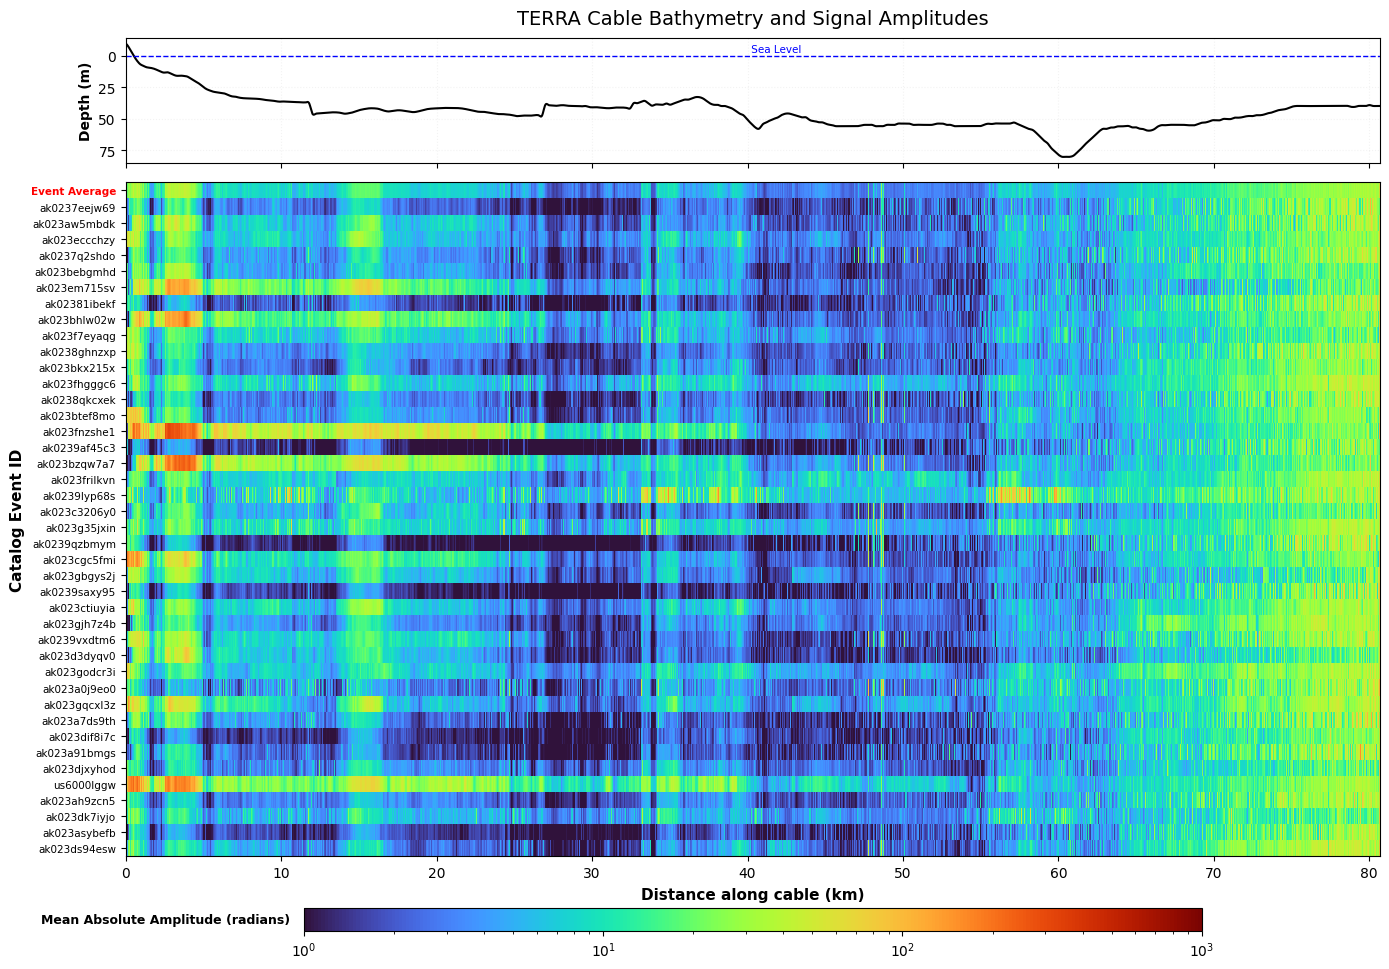

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import dascore as dc
import os
from matplotlib.colors import LogNorm

def load_coords(filepath):
    """
    Loads .xycz file, fixes longitude, and calculates cumulative distance.
    Includes na_values to ensure empty spaces are recognized as NaN.
    """
    df = pd.read_csv(
        filepath, 
        sep=r'\s+', 
        header=None,
        names=['lon','lat','cha','dep'],
        na_values=['', ' ', 'NaN', 'nan']
    ).dropna(how='any')

    df['lon'] = df['lon'].apply(lambda x: x - 360 if x > 180 else x)

    # Haversine distance calculation
    R = 6371.0
    lat, lon = np.radians(df['lat'].values), np.radians(df['lon'].values)
    dlat, dlon = np.diff(lat), np.diff(lon)
    a = (np.sin(dlat/2)**2
         + np.cos(lat[:-1])
         * np.cos(lat[1:])
         * np.sin(dlon/2)**2)

    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

    dist_km = np.insert(R * c, 0, 0).cumsum()
    df['dist_km'] = dist_km

    return df

def get_noise_row_masked(f_path, target_channels):
    """
    Extracts Mean Absolute Amplitude (MAA).
    """
    if not os.path.exists(f_path):
        return None
    try:
        patch = dc.spool(f_path)[0]
        sub = patch.detrend("time")

        raw_maa = np.squeeze(sub.abs().mean(dim="time").data)
        row_output = np.full(len(target_channels), np.nan)

        for i, cha_idx in enumerate(target_channels):
            cha_idx = int(cha_idx)
            if cha_idx >= 74 and 0 <= cha_idx < len(raw_maa):
                row_output[i] = raw_maa[cha_idx]

        return row_output
    except Exception as e:
        print(f"Error processing {os.path.basename(f_path)}: {e}")
        return None

base_dir = "/Users/ed/research_code/das"
noise_game_dir = os.path.join(base_dir, "das_records/good-events-3.2-up")
coords_path = os.path.join(base_dir, 'das_coords_bathymetry/TERRA_coords.xycz')

figures_dir = os.path.join(base_dir, "das_figures")
os.makedirs(figures_dir, exist_ok=True)
fig_output_path = os.path.join(figures_dir, "TERRA_bathymetry_noise.png")

good_terra_events = [
    "ak0237eejw69_TERRA.h5", "ak023aw5mbdk_TERRA.h5", "ak023eccchzy_TERRA.h5",
    "ak0237q2shdo_TERRA.h5", "ak023bebgmhd_TERRA.h5", "ak023em715sv_TERRA.h5",
    "ak02381ibekf_TERRA.h5", "ak023bhlw02w_TERRA.h5", "ak023f7eyaqg_TERRA.h5",
    "ak0238ghnzxp_TERRA.h5", "ak023bkx215x_TERRA.h5", "ak023fhgggc6_TERRA.h5",
    "ak0238qkcxek_TERRA.h5", "ak023btef8mo_TERRA.h5", "ak023fnzshe1_TERRA.h5",
    "ak0239af45c3_TERRA.h5", "ak023bzqw7a7_TERRA.h5", "ak023frilkvn_TERRA.h5",
    "ak0239lyp68s_TERRA.h5", "ak023c3206y0_TERRA.h5", "ak023g35jxin_TERRA.h5",
    "ak0239qzbmym_TERRA.h5", "ak023cgc5fmi_TERRA.h5", "ak023gbgys2j_TERRA.h5",
    "ak0239saxy95_TERRA.h5", "ak023ctiuyia_TERRA.h5", "ak023gjh7z4b_TERRA.h5",
    "ak0239vxdtm6_TERRA.h5", "ak023d3dyqv0_TERRA.h5", "ak023godcr3i_TERRA.h5",
    "ak023a0j9eo0_TERRA.h5", "ak023gqcxl3z_TERRA.h5", "ak023a7ds9th_TERRA.h5",
    "ak023dif8i7c_TERRA.h5", "ak023a91bmgs_TERRA.h5", "ak023djxyhod_TERRA.h5",
    "us6000lggw_TERRA.h5", "ak023ah9zcn5_TERRA.h5", "ak023dk7iyjo_TERRA.h5",
    "ak023asybefb_TERRA.h5", "ak023ds94esw_TERRA.h5"
]

terra_coords = load_coords(coords_path)
target_channels = terra_coords['cha'].values

data_matrix = []
valid_labels = []

for fname in good_terra_events:
    row = get_noise_row_masked(os.path.join(noise_game_dir, fname),
                               target_channels)
    if row is not None:
        data_matrix.append(row)
        valid_labels.append(fname.split('_')[0])

if not data_matrix:
    print("Error: No data found.")
else:
    avg_row = np.nanmean(data_matrix, axis=0)
    data_matrix.insert(0, avg_row)
    valid_labels.insert(0, "Event Average")

    Z = np.array(data_matrix)
    Z[Z <= 0] = 1e-10

    X_orig = terra_coords['dist_km'].values
    X_edges = np.zeros(len(X_orig) + 1)
    X_edges[1:-1] = (X_orig[:-1] + X_orig[1:]) / 2.0
    X_edges[0] = X_orig[0] - (X_orig[1] - X_orig[0]) / 2.0
    X_edges[-1] = X_orig[-1] + (X_orig[-1] - X_orig[-2]) / 2.0
    Y_edges = np.arange(len(valid_labels) + 1)

    fig, (ax_bath, ax_noise) = plt.subplots(2, 1, figsize=(14, 10),
                                            gridspec_kw={'height_ratios':
                                                         [1, 6]}, sharex=True)
    plt.subplots_adjust(hspace=0.02, bottom=0.1)

    # Bathymetry plot
    ax_bath.plot(X_orig, -terra_coords['dep'], color='black', lw=1.5)
    ax_bath.axhline(0, color='blue', linestyle='--', lw=1)
    ax_bath.text(40, -1, " Sea Level", color='blue', va='bottom', fontsize=7.5)

    ax_bath.invert_yaxis()
    ax_bath.set_ylabel("Depth (m)", fontsize=10, fontweight='bold')
    ax_bath.set_title("TERRA Cable Bathymetry and Signal Amplitudes",
                      fontsize=14, pad=10)
    ax_bath.grid(True, alpha=0.15, linestyle=':')

    # Noise plot
    mesh = ax_noise.pcolormesh(X_edges, Y_edges, Z,
                               norm=LogNorm(vmin=1, vmax=1000),
                               cmap='turbo', shading='flat')

    ax_noise.set_yticks(np.arange(len(valid_labels)) + 0.5)
    ax_noise.set_yticklabels(valid_labels, fontsize=7.5)

    labels = ax_noise.get_yticklabels()
    labels[0].set_fontweight('bold')
    labels[0].set_color('red')

    ax_noise.invert_yaxis()
    ax_noise.set_ylabel("Catalog Event ID", fontsize=11, fontweight='bold')
    ax_noise.set_xlabel("Distance along cable (km)", fontsize=11,
                        fontweight='bold', labelpad=5)

    cbar = plt.colorbar(mesh, ax=ax_noise, orientation='horizontal', pad=0.07,
                        fraction=0.03, aspect=40)
    cbar.ax.set_ylabel('Mean Absolute Amplitude (radians)', rotation=0,
                       va='center', ha='right', fontsize=9, fontweight='bold')
    cbar.ax.yaxis.set_label_coords(-0.015, 0.5)

    plt.tight_layout(rect=[0, 0, 1, 0.98])

    print(f"Saving figure to: {fig_output_path}")
    plt.savefig(fig_output_path, bbox_inches='tight', dpi=300)
    plt.show()

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import dascore as dc
import os
from matplotlib.colors import LogNorm

def load_coords(filepath):
    """
    Loads .xycz file, fixes longitude, and calculates cumulative distance.
    Includes na_values to ensure empty spaces are recognized as NaN.
    """
    df = pd.read_csv(
        filepath, 
        sep=r'\s+', 
        header=None,
        names=['lon','lat','cha','dep'],
        na_values=['', ' ', 'NaN', 'nan']
    ).dropna(how='any')

    df['lon'] = df['lon'].apply(lambda x: x - 360 if x > 180 else x)

    # Haversine distance calculation
    R = 6371.0
    lat, lon = np.radians(df['lat'].values), np.radians(df['lon'].values)
    dlat, dlon = np.diff(lat), np.diff(lon)
    a = (np.sin(dlat/2)**2
         + np.cos(lat[:-1])
         * np.cos(lat[1:])
         * np.sin(dlon/2)**2)

    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

    dist_km = np.insert(R * c, 0, 0).cumsum()
    df['dist_km'] = dist_km

    return df

def get_amplitude_rows(f_path, target_channels):
    """
    Extracts two rows: 
    1. Mean Absolute Amplitude (MAA) of the last 20 seconds (Noise).
    2. Maximum Absolute Amplitude (MaxAA) of the full timespan (Signal).
    """
    if not os.path.exists(f_path):
        return None, None
    try:
        patch = dc.spool(f_path)[0].detrend("time")
        
        t_max = patch.coords.max('time')
        t_noise_start = t_max - np.timedelta64(20, 's')
        noise_patch = patch.select(time=(t_noise_start, t_max))
        raw_noise = np.squeeze(noise_patch.abs().mean(dim="time").data)
        raw_signal = np.squeeze(patch.abs().max(dim="time").data)
        noise_row = np.full(len(target_channels), np.nan)
        signal_row = np.full(len(target_channels), np.nan)

        for i, cha_idx in enumerate(target_channels):
            cha_idx = int(cha_idx)
            # Assuming same channel masking logic as before (>= 74)
            if cha_idx >= 74 and 0 <= cha_idx < len(raw_noise):
                noise_row[i] = raw_noise[cha_idx]
                signal_row[i] = raw_signal[cha_idx]

        return noise_row, signal_row
    except Exception as e:
        print(f"Error processing {os.path.basename(f_path)}: {e}")
        return None, None

def plot_and_save(terra_coords, data_matrix, valid_labels, title, output_path, vmin, vmax):
    """
    Helper to generate the dual-axes plot (Bathymetry + Heatmap) without colorbar.
    """
    avg_row = np.nanmean(data_matrix, axis=0)
    data_matrix_with_avg = [avg_row] + data_matrix
    labels_with_avg = ["Event Average"] + valid_labels

    Z = np.array(data_matrix_with_avg)
    Z[Z <= 0] = 1e-10

    X_orig = terra_coords['dist_km'].values
    X_edges = np.zeros(len(X_orig) + 1)
    X_edges[1:-1] = (X_orig[:-1] + X_orig[1:]) / 2.0
    X_edges[0] = X_orig[0] - (X_orig[1] - X_orig[0]) / 2.0
    X_edges[-1] = X_orig[-1] + (X_orig[-1] - X_orig[-2]) / 2.0
    Y_edges = np.arange(len(labels_with_avg) + 1)

    fig, (ax_bath, ax_data) = plt.subplots(2, 1, figsize=(14, 10),
                                           gridspec_kw={'height_ratios': [1, 6]}, 
                                           sharex=True)
    plt.subplots_adjust(hspace=0.02, bottom=0.1)

    ax_bath.plot(X_orig, -terra_coords['dep'], color='black', lw=1.5)
    ax_bath.axhline(0, color='blue', linestyle='--', lw=1)
    ax_bath.text(40, -1, " Sea Level", color='blue', va='bottom', fontsize=7.5)
    ax_bath.invert_yaxis()
    ax_bath.set_ylabel("Depth (m)", fontsize=10, fontweight='bold')
    ax_bath.set_title(title, fontsize=14, pad=10)
    ax_bath.grid(True, alpha=0.15, linestyle=':')

    mesh = ax_data.pcolormesh(X_edges, Y_edges, Z,
                               norm=LogNorm(vmin=vmin, vmax=vmax),
                               cmap='turbo', shading='flat')

    ax_data.set_yticks(np.arange(len(labels_with_avg)) + 0.5)
    ax_data.set_yticklabels(labels_with_avg, fontsize=7.5)

    yticklabels = ax_data.get_yticklabels()
    yticklabels[0].set_fontweight('bold')
    yticklabels[0].set_color('red')

    ax_data.invert_yaxis()
    ax_data.set_ylabel("Catalog Event ID", fontsize=11, fontweight='bold')
    ax_data.set_xlabel("Distance along cable (km)", fontsize=11, fontweight='bold', labelpad=5)    
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    print(f"Saving figure to: {output_path}")
    plt.savefig(output_path, bbox_inches='tight', dpi=300)
    plt.close(fig)

base_dir = "/Users/ed/research_code/das"
noise_game_dir = os.path.join(base_dir, "das_records/good-events-3.2-up")
coords_path = os.path.join(base_dir, 'das_coords_bathymetry/TERRA_coords.xycz')

figures_dir = os.path.join(base_dir, "das_figures")
os.makedirs(figures_dir, exist_ok=True)

good_terra_events = [
    "ak0237eejw69_TERRA.h5", "ak023aw5mbdk_TERRA.h5", "ak023eccchzy_TERRA.h5",
    "ak0237q2shdo_TERRA.h5", "ak023bebgmhd_TERRA.h5", "ak023em715sv_TERRA.h5",
    "ak02381ibekf_TERRA.h5", "ak023bhlw02w_TERRA.h5", "ak023f7eyaqg_TERRA.h5",
    "ak0238ghnzxp_TERRA.h5", "ak023bkx215x_TERRA.h5", "ak023fhgggc6_TERRA.h5",
    "ak0238qkcxek_TERRA.h5", "ak023btef8mo_TERRA.h5", "ak023fnzshe1_TERRA.h5",
    "ak0239af45c3_TERRA.h5", "ak023bzqw7a7_TERRA.h5", "ak023frilkvn_TERRA.h5",
    "ak0239lyp68s_TERRA.h5", "ak023c3206y0_TERRA.h5", "ak023g35jxin_TERRA.h5",
    "ak0239qzbmym_TERRA.h5", "ak023cgc5fmi_TERRA.h5", "ak023gbgys2j_TERRA.h5",
    "ak0239saxy95_TERRA.h5", "ak023ctiuyia_TERRA.h5", "ak023gjh7z4b_TERRA.h5",
    "ak0239vxdtm6_TERRA.h5", "ak023d3dyqv0_TERRA.h5", "ak023godcr3i_TERRA.h5",
    "ak023a0j9eo0_TERRA.h5", "ak023gqcxl3z_TERRA.h5", "ak023a7ds9th_TERRA.h5",
    "ak023dif8i7c_TERRA.h5", "ak023a91bmgs_TERRA.h5", "ak023djxyhod_TERRA.h5",
    "us6000lggw_TERRA.h5", "ak023ah9zcn5_TERRA.h5", "ak023dk7iyjo_TERRA.h5",
    "ak023asybefb_TERRA.h5", "ak023ds94esw_TERRA.h5"
]

terra_coords = load_coords(coords_path)
target_channels = terra_coords['cha'].values

noise_matrix = []
signal_matrix = []
valid_labels = []

for fname in good_terra_events:
    n_row, s_row = get_amplitude_rows(os.path.join(noise_game_dir, fname), target_channels)
    if n_row is not None:
        noise_matrix.append(n_row)
        signal_matrix.append(s_row)
        valid_labels.append(fname.split('_')[0])

if not noise_matrix:
    print("Error: No data found.")
else:
    plot_and_save(
        terra_coords, noise_matrix, valid_labels,
        "TERRA: Mean Amplitude (Last 20s Noise)",
        os.path.join(figures_dir, "TERRA_noise_floor.png"),
        vmin=1, vmax=1000
    )

    plot_and_save(
        terra_coords, signal_matrix, valid_labels,
        "TERRA: Maximum Amplitude (Signal Window)",
        os.path.join(figures_dir, "TERRA_signal_max.png"),
        vmin=1, vmax=1000
    )

Saving figure to: /Users/ed/research_code/das/das_figures/TERRA_noise_floor.png
Saving figure to: /Users/ed/research_code/das/das_figures/TERRA_signal_max.png
